# Fake Speech Data Plots\n
\n
This notebook builds the 5 requested visualizations from `recordings/fake_speech_dataset.json`.

In [1]:
# Optional: install dependencies if missing (run once).\n
# Uncomment if needed:\n
# %pip install numpy matplotlib pandas ipywidgets\n

import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
DATA_PATH = Path('recordings/fake_speech_dataset.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Could not find: {DATA_PATH}. Run generate_fake_speech_data.py first.')

data = json.loads(DATA_PATH.read_text(encoding='utf-8'))
recordings = data['recordings']
recording_ids = [r['recording_id'] for r in recordings]
filler_words = ['um', 'uh', 'you know', 'like']

print(f"Loaded {len(recordings)} recordings")
print(f"Total words: {data['total_words']}")
print(f"Total fillers: {data['total_filler_words']} ({data['overall_filler_percentage']}%)")

Loaded 8 recordings
Total words: 3151
Total fillers: 516 (16.38%)


## 1) Filler word position density per recording\n
\n
This shows whether fillers cluster near the start or are spread across each recording.

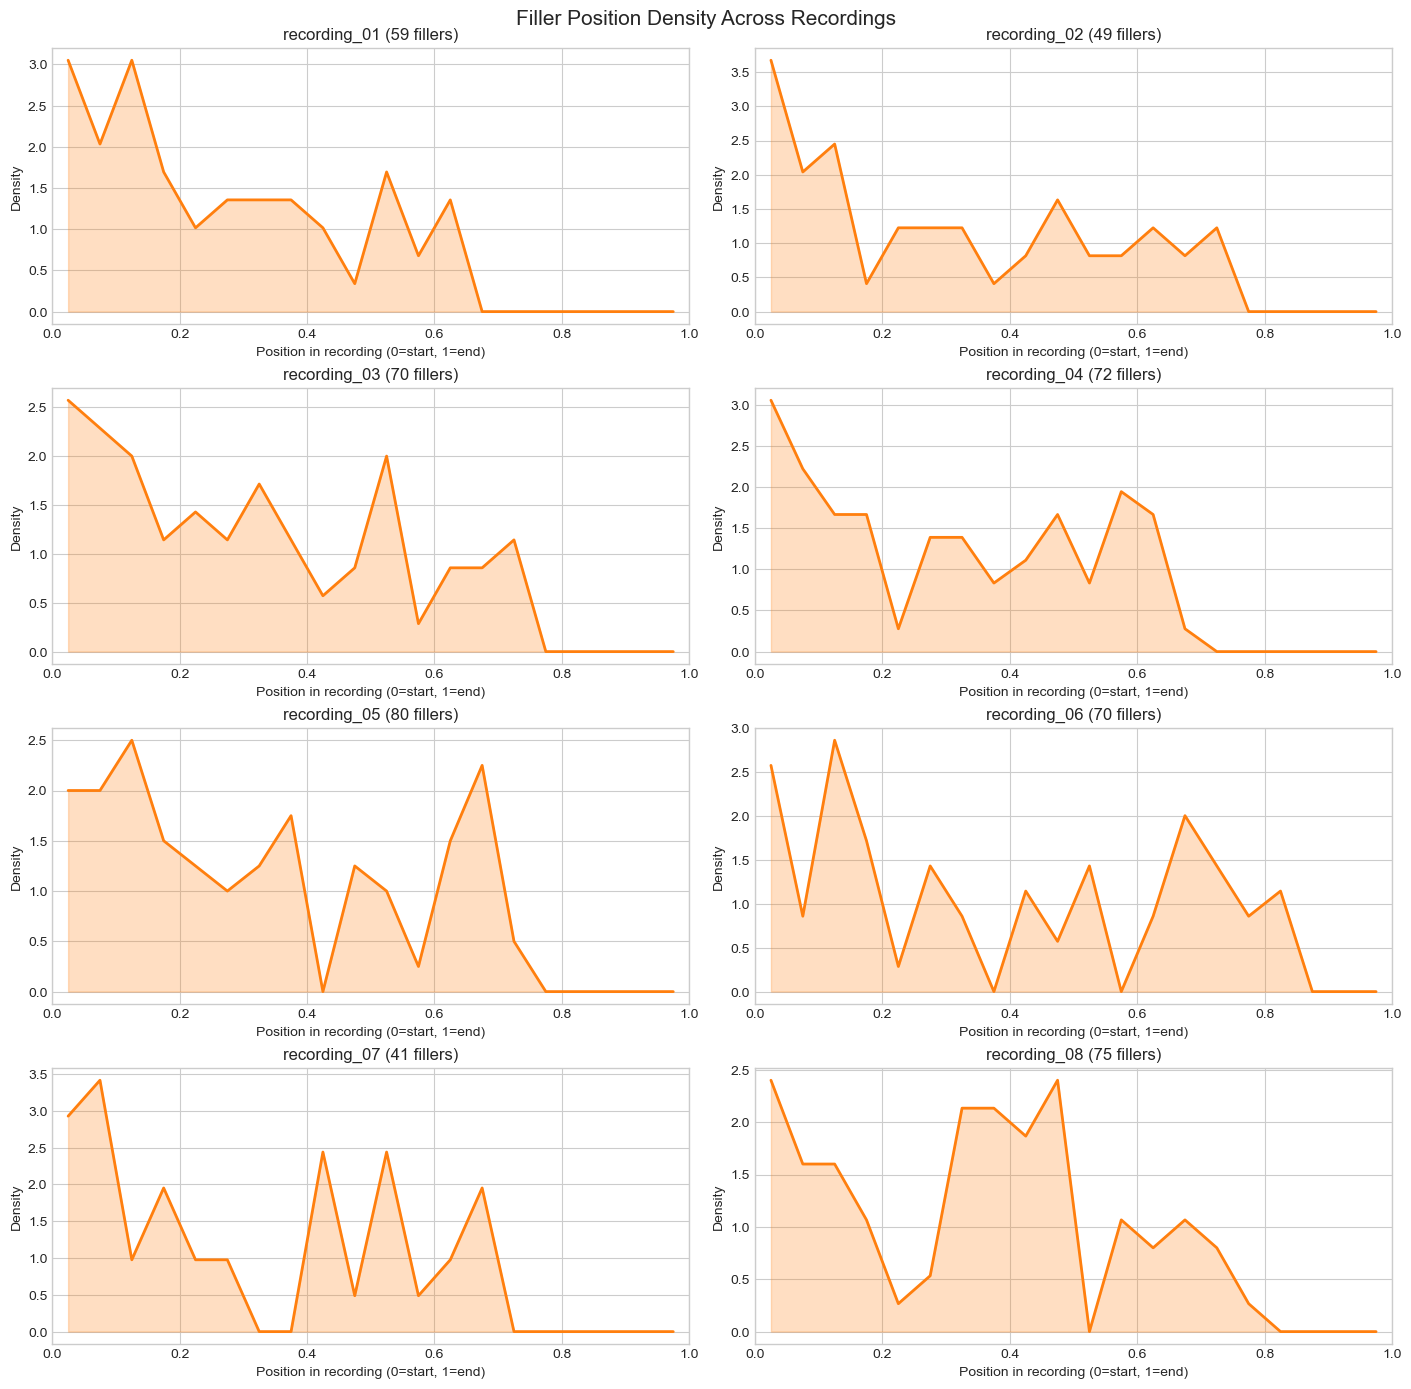

In [3]:
n = len(recordings)
cols = 2
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.4 * rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, rec in enumerate(recordings):
    ax = axes[idx]
    positions = [e['position_ratio'] for e in rec.get('filler_events', [])]
    if len(positions) > 1:
        bins = np.linspace(0, 1, 21)
        hist, edges = np.histogram(positions, bins=bins, density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.fill_between(centers, hist, alpha=0.25, color='tab:orange')
        ax.plot(centers, hist, linewidth=2, color='tab:orange')
    elif len(positions) == 1:
        ax.axvline(positions[0], color='tab:orange', linewidth=2)
    else:
        ax.text(0.5, 0.5, 'No fillers', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f"{rec['recording_id']} ({len(positions)} fillers)")
    ax.set_xlim(0, 1)
    ax.set_xlabel('Position in recording (0=start, 1=end)')
    ax.set_ylabel('Density')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('Filler Position Density Across Recordings', y=1.01, fontsize=15)
plt.show()

## 2) Filler words over time (line plot)\n
\n
Equivalent to your Social Data Story-style plot: x=time, y=count, one line per filler word.

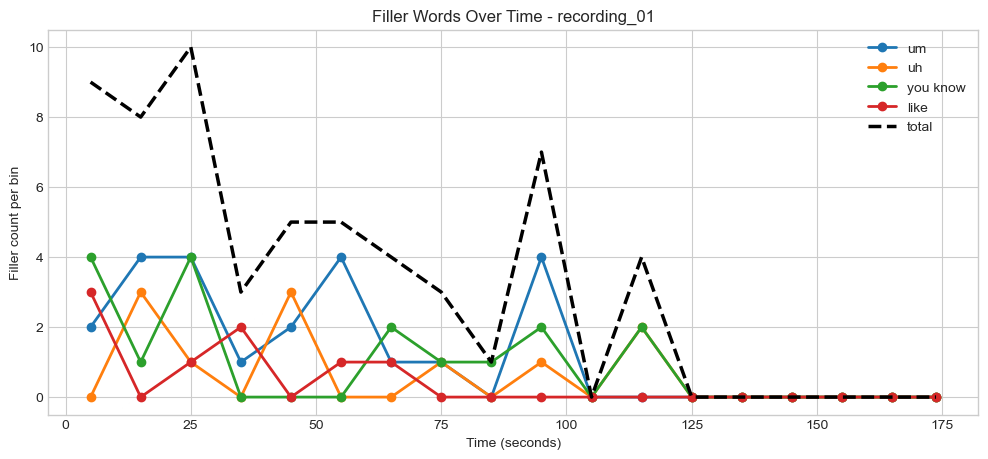

In [4]:
selected_id = recording_ids[0]  # Change this to another recording_id\n
rec = next(r for r in recordings if r['recording_id'] == selected_id)
bins = rec['filler_time_bins']
times = [(b['time_start'] + b['time_end']) / 2 for b in bins]

plt.figure(figsize=(12, 5))
for w in filler_words:
    plt.plot(times, [b.get(w, 0) for b in bins], marker='o', linewidth=2, label=w)

plt.plot(times, [b.get('total', 0) for b in bins], color='black', linewidth=2.5, linestyle='--', label='total')
plt.title(f"Filler Words Over Time - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Filler count per bin')
plt.legend()
plt.show()

## 3) Pace over time (rolling 30-second WPM)

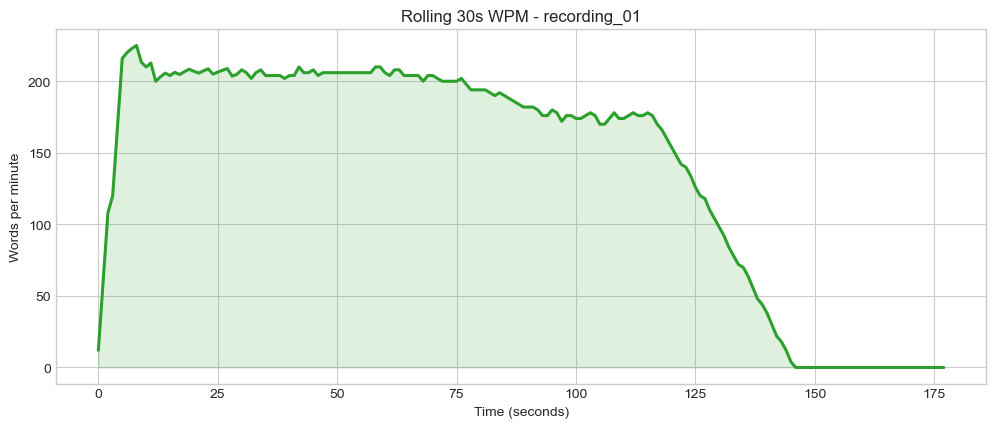

In [5]:
selected_id = recording_ids[0]  # Change as needed\n
rec = next(r for r in recordings if r['recording_id'] == selected_id)
rw = rec['rolling_wpm_30s']
times = [p['time'] for p in rw]
wpm = [p['wpm'] for p in rw]

plt.figure(figsize=(12, 4.6))
plt.plot(times, wpm, color='tab:green', linewidth=2.2)
plt.fill_between(times, wpm, alpha=0.15, color='tab:green')
plt.title(f"Rolling 30s WPM - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Words per minute')
plt.show()

## 4) Filler words word cloud + click/drill-down info\n
\n
This uses a pseudo word-cloud in matplotlib (font size = frequency) and an interactive selector for details.

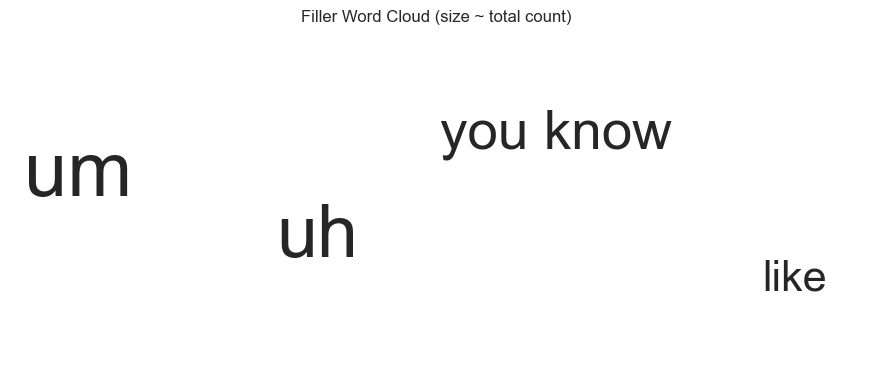

Click-style details: choose a word below (requires ipywidgets).


In [6]:
summary = data['filler_word_summary']
summary_map = {item['word']: item for item in summary}
words_sorted = sorted(summary_map.keys(), key=lambda w: summary_map[w]['count'], reverse=True)
counts = np.array([summary_map[w]['count'] for w in words_sorted], dtype=float)
sizes = 18 + (counts / counts.max()) * 38

plt.figure(figsize=(11, 4.5))
x_positions = np.linspace(0.08, 0.92, len(words_sorted))
y_positions = [0.58, 0.40, 0.70, 0.28, 0.82, 0.50, 0.66, 0.34][:len(words_sorted)]
for i, w in enumerate(words_sorted):
    plt.text(x_positions[i], y_positions[i], w, fontsize=float(sizes[i]), ha='center', va='center', transform=plt.gca().transAxes)

plt.title('Filler Word Cloud (size ~ total count)')
plt.axis('off')
plt.show()

print('Click-style details: choose a word below (requires ipywidgets).')

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    dropdown = widgets.Dropdown(options=words_sorted, description='Word:')
    out = widgets.Output()

    def show_info(change=None):
        with out:
            out.clear_output()
            word = dropdown.value
            info = summary_map[word]
            print(f"Word: {word}")
            print(f"Total times used: {info['count']}")
            print(f"Used in recordings: {info['recording_count']}")

    dropdown.observe(show_info, names='value')
    show_info()
    display(dropdown, out)
except Exception as exc:
    print('ipywidgets not available. Install with: %pip install ipywidgets')
    print(f'Fallback: {exc}')
    for w in words_sorted:
        info = summary_map[w]
        print(f"- {w}: {info['count']} uses across {info['recording_count']} recordings")

Dropdown(description='Word:', options=('um', 'uh', 'you know', 'like'), value='um')

Output()

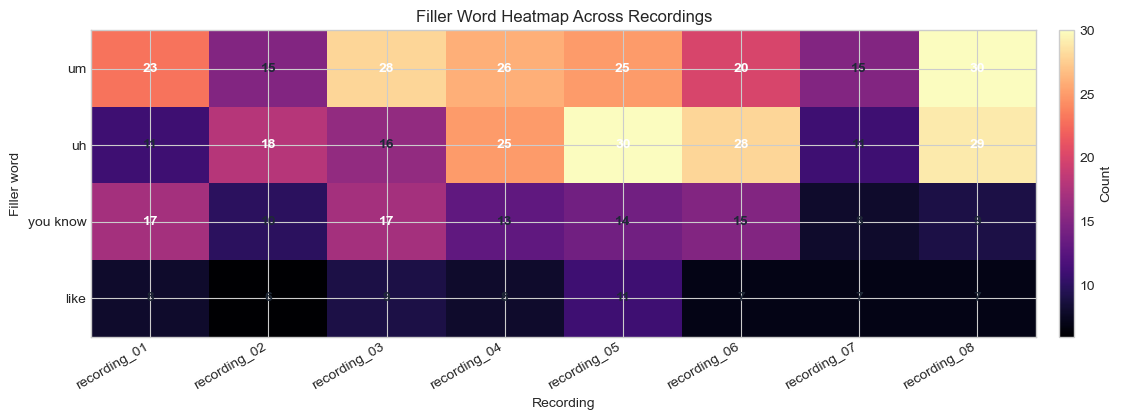

In [11]:
filler_order = sorted(summary_map.keys(), key=lambda w: summary_map[w]['count'], reverse=True)
heatmap = np.array(
    [
        [sum(1 for event in rec.get('filler_events', []) if event['word'] == word) for rec in recordings]
        for word in filler_order
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(12.5, max(3.8, 0.7 * len(filler_order) + 1.5)))
im = ax.imshow(heatmap, cmap='magma', aspect='auto')

ax.set_xticks(np.arange(len(recording_ids)))
ax.set_xticklabels(recording_ids, rotation=30, ha='right')
ax.set_yticks(np.arange(len(filler_order)))
ax.set_yticklabels(filler_order)
ax.set_xlabel('Recording')
ax.set_ylabel('Filler word')
ax.set_title('Filler Word Heatmap Across Recordings')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Count')

peak = float(heatmap.max()) if heatmap.size else 0.0
threshold = peak * 0.55
for row_idx in range(heatmap.shape[0]):
    for col_idx in range(heatmap.shape[1]):
        count = int(heatmap[row_idx, col_idx])
        if count:
            text_color = 'white' if count >= threshold else '#1f2937'
            ax.text(
                col_idx,
                row_idx,
                str(count),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color,
            )

ax.set_xlim(-0.5, len(recording_ids) - 0.5)
ax.set_ylim(len(filler_order) - 0.5, -0.5)
plt.tight_layout()
plt.show()

## 5) Filler word heatmap

This view shows how often each filler word appears in each recording. Rows are sorted by overall frequency so the densest words stand out first.

## 6) Pitch variation plots

Useful pair of plots:

1. Smoothed pitch contour for one recording (within-recording trend).
2. Median + range across recordings (between-recording comparison).

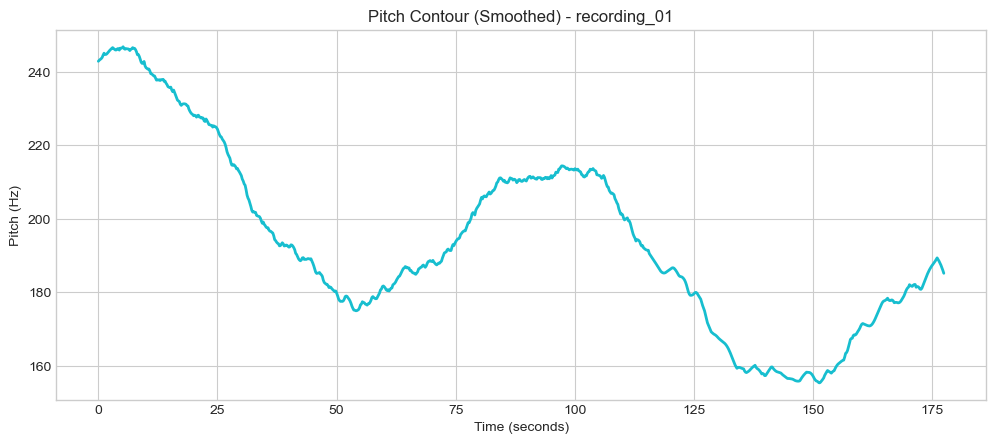

In [8]:
selected_id = recording_ids[0]  # Change as needed\n
rec = next(r for r in recordings if r['recording_id'] == selected_id)
track = rec['pitch_track']

times = np.array([p['time'] for p in track], dtype=float)
pitch = np.array([np.nan if p['pitch_hz'] is None else p['pitch_hz'] for p in track], dtype=float)

valid = ~np.isnan(pitch)
if valid.sum() == 0:
    raise ValueError('No voiced pitch values in selected recording.')

interp_pitch = np.interp(times, times[valid], pitch[valid])
window = 7
kernel = np.ones(window) / window
smooth_pitch = np.convolve(np.pad(interp_pitch, (window//2, window//2), mode='edge'), kernel, mode='valid')

plt.figure(figsize=(12, 4.8))
plt.plot(times, smooth_pitch, color='tab:cyan', linewidth=2)
plt.title(f"Pitch Contour (Smoothed) - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Pitch (Hz)')
plt.show()

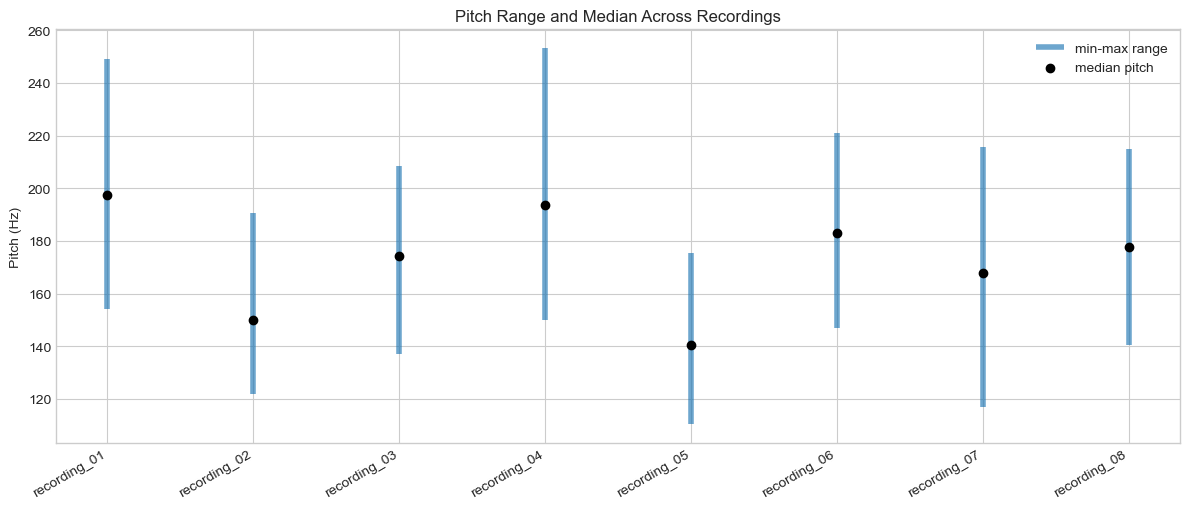

In [9]:
ids = [r['recording_id'] for r in recordings]
medians = [r['pitch_summary']['median_hz'] for r in recordings]
mins = [r['pitch_summary']['min_hz'] for r in recordings]
maxs = [r['pitch_summary']['max_hz'] for r in recordings]

x = np.arange(len(ids))
plt.figure(figsize=(12, 5.2))
plt.vlines(x, mins, maxs, color='tab:blue', alpha=0.65, linewidth=4, label='min-max range')
plt.scatter(x, medians, color='black', zorder=3, label='median pitch')
plt.xticks(x, ids, rotation=30, ha='right')
plt.ylabel('Pitch (Hz)')
plt.title('Pitch Range and Median Across Recordings')
plt.legend()
plt.tight_layout()
plt.show()

## Optional next steps\n
- Change `selected_id` in the relevant cells to inspect another recording.\n
- Regenerate fake data with another seed and rerun the notebook.\n
- Add export cells (`plt.savefig(...)`) for static report figures.